In [25]:
import pandas as pd

new_data = pd.DataFrame([[6, 85, 7]], 
                        columns=["hours_studied", "attendance", "sleep_hours"])



In [3]:
import os
os.getcwd()


'/Users/medhasingh/student-ml-project'

In [4]:
os.listdir()#checking files in this folder


['Untitled1.ipynb',
 'Untitled.ipynb',
 '.ipynb_checkpoints',
 'venv',
 'student_data.c',
 'untitled.py']

In [5]:
import os
os.listdir()


['Untitled1.ipynb',
 'student_data.csv',
 'Untitled.ipynb',
 '.ipynb_checkpoints',
 'venv',
 'untitled.py']

In [6]:
df = pd.read_csv("student_data.csv")
df.head()


,hours_studied,attendance,sleep_hours,marks
0,2,50,5,40
1,3,60,6,50
2,4,65,6,55
3,5,70,7,65
4,6,80,7,75


In [8]:
df.info()#structure

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   hours_studied  10 non-null     int64
 1   attendance     10 non-null     int64
 2   sleep_hours    10 non-null     int64
 3   marks          10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [9]:
df.describe()#stasticial summary

,hours_studied,attendance,sleep_hours,marks
count,10.00000,10.000000,10.000000,10.000000
mean,5.50000,73.300000,6.800000,68.300000
std,3.02765,19.579184,1.549193,23.990971
min,1.00000,40.000000,4.000000,30.000000
25%,3.25000,61.250000,6.000000,51.250000
50%,5.50000,75.000000,7.000000,70.000000
75%,7.75000,88.750000,8.000000,88.750000
max,10.00000,98.000000,9.000000,98.000000


In [10]:
df.isnull().sum()#checking missing values


hours_studied    0
attendance       0
sleep_hours      0
marks            0
dtype: int64

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


<function matplotlib.pyplot.show(close=None, block=None)>

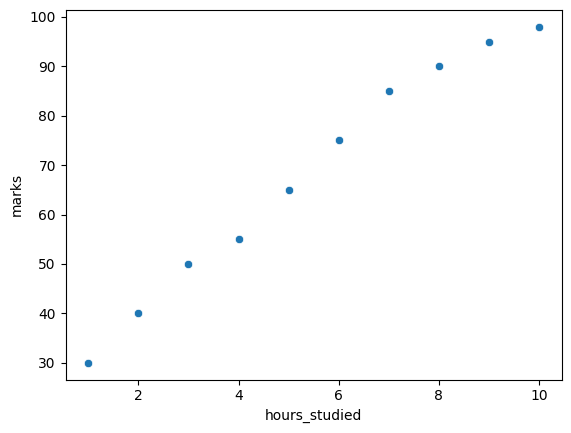

In [14]:
sns.scatterplot(x="hours_studied",y="marks",data=df) #hours studied vs marks (if points go upwards,it means directly proportional)
plt.show

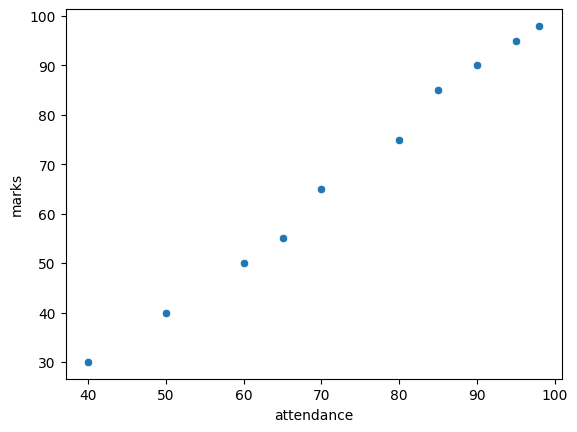

In [15]:
sns.scatterplot(x="attendance", y="marks", data=df) #attendance vs marks
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

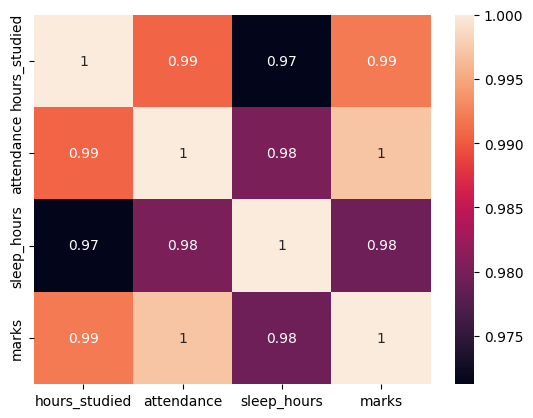

In [17]:
sns.heatmap(df.corr(), annot=True) #strongest predictor among given features
plt.show

In [18]:
X = df[["hours_studied", "attendance", "sleep_hours"]]
y = df["marks"]

In [19]:
from sklearn.model_selection import train_test_split#data split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
predictions = model.predict(X_test)
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print(mse)

1.9452096363149818


In [26]:
model.predict(new_data)

array([79.36372916])

In [27]:
print(model.coef_)

[1.88924804 0.8758081  0.62095951]
